# 🏠 Analyse et Modélisation des Prix Immobiliers

Pipeline complet :
1. Chargement des données
2. EDA visuelle
3. Nettoyage — `src/preprocessing.py`
4. Feature Engineering — `src/feature_engineering.py`
5. Modélisation — `src/modeling.py`
6. Comparaison des performances
7. Analyse des biais par quartier
8. Sauvegarde du meilleur pipeline

In [55]:
# ===============================
# Imports
# ===============================
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modules internes — src/
from src.preprocessing      import handle_missing_values, remove_outliers_iqr, encode_categorical
from src.feature_engineering import create_features
from src.modeling            import (train_linear_regression, train_random_forest,
                                     train_gradient_boosting, evaluate_model)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('✅ Imports OK')

✅ Imports OK


---
## 1️⃣ Chargement des données

In [56]:
train_df = pd.read_csv('../data/train.csv')
test_df  = pd.read_csv('../data/test.csv')

print(f'Train : {train_df.shape[0]} lignes, {train_df.shape[1]} colonnes')
print(f'Test  : {test_df.shape[0]} lignes, {test_df.shape[1]} colonnes')
train_df.head()

Train : 1460 lignes, 81 colonnes
Test  : 1459 lignes, 80 colonnes


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## 2️⃣ Exploration des données (EDA)

In [57]:
# Valeurs manquantes
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Colonnes avec valeurs manquantes : {len(missing)}\n')
print(missing.head(20))

Colonnes avec valeurs manquantes : 19

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


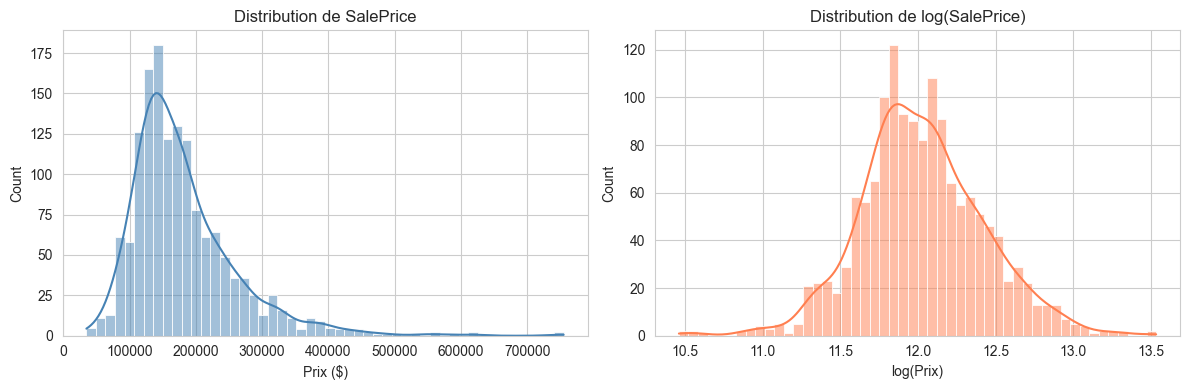

Prix moyen  : 180,921 $
Prix médian : 163,000 $
Prix min    : 34,900 $
Prix max    : 755,000 $


In [58]:
# Distribution de SalePrice
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train_df['SalePrice'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution de SalePrice')
axes[0].set_xlabel('Prix ($)')

sns.histplot(np.log1p(train_df['SalePrice']), bins=50, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Distribution de log(SalePrice)')
axes[1].set_xlabel('log(Prix)')

plt.tight_layout()
plt.show()

print(f"Prix moyen  : {train_df['SalePrice'].mean():,.0f} $")
print(f"Prix médian : {train_df['SalePrice'].median():,.0f} $")
print(f"Prix min    : {train_df['SalePrice'].min():,.0f} $")
print(f"Prix max    : {train_df['SalePrice'].max():,.0f} $")

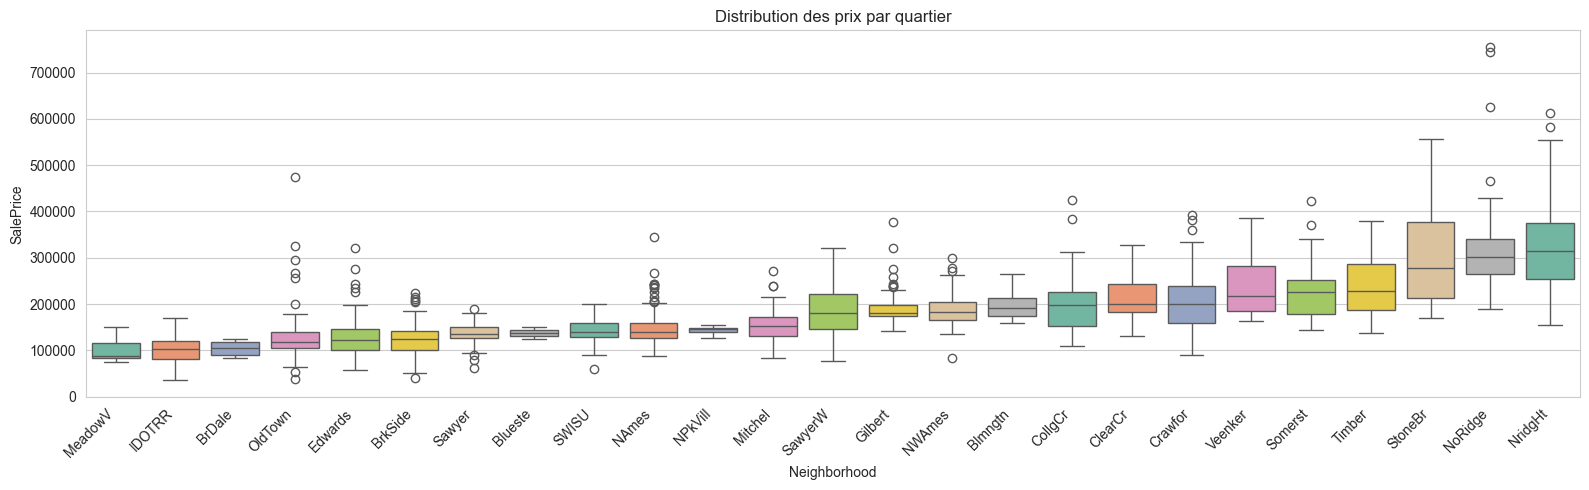

In [59]:
# Boxplot par quartier
order = train_df.groupby('Neighborhood')['SalePrice'].median().sort_values().index

plt.figure(figsize=(16, 5))
sns.boxplot(x='Neighborhood', y='SalePrice', data=train_df,
            order=order, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution des prix par quartier')
plt.tight_layout()
plt.show()

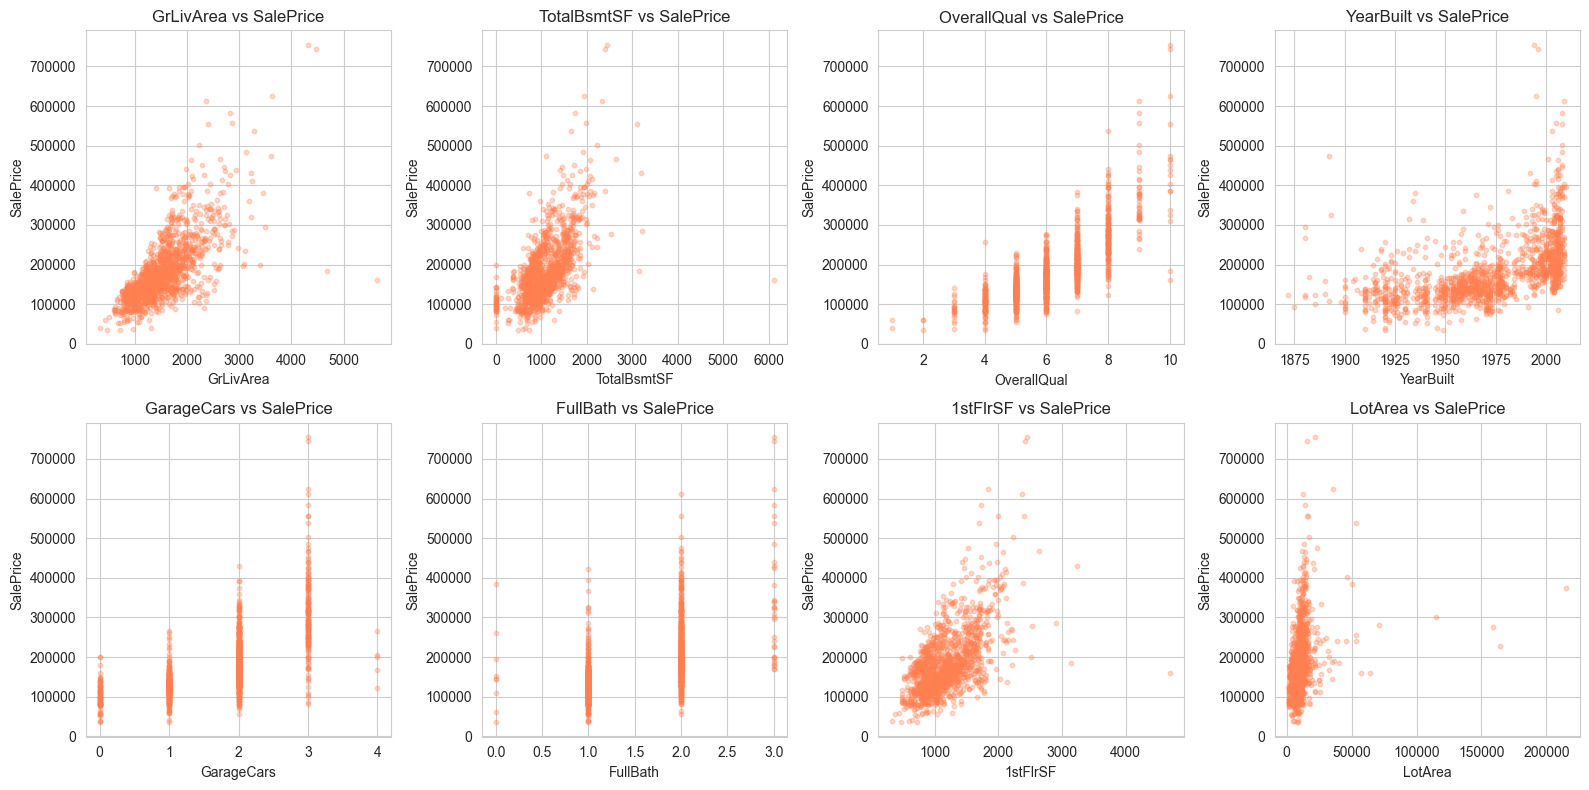

In [60]:
# Scatter plots : features importantes vs SalePrice
num_features = ['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt',
                'GarageCars', 'FullBath', '1stFlrSF', 'LotArea']
num_features = [f for f in num_features if f in train_df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(num_features):
    axes[i].scatter(train_df[feat], train_df['SalePrice'],
                    alpha=0.3, color='coral', s=10)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feat} vs SalePrice')
plt.tight_layout()
plt.show()

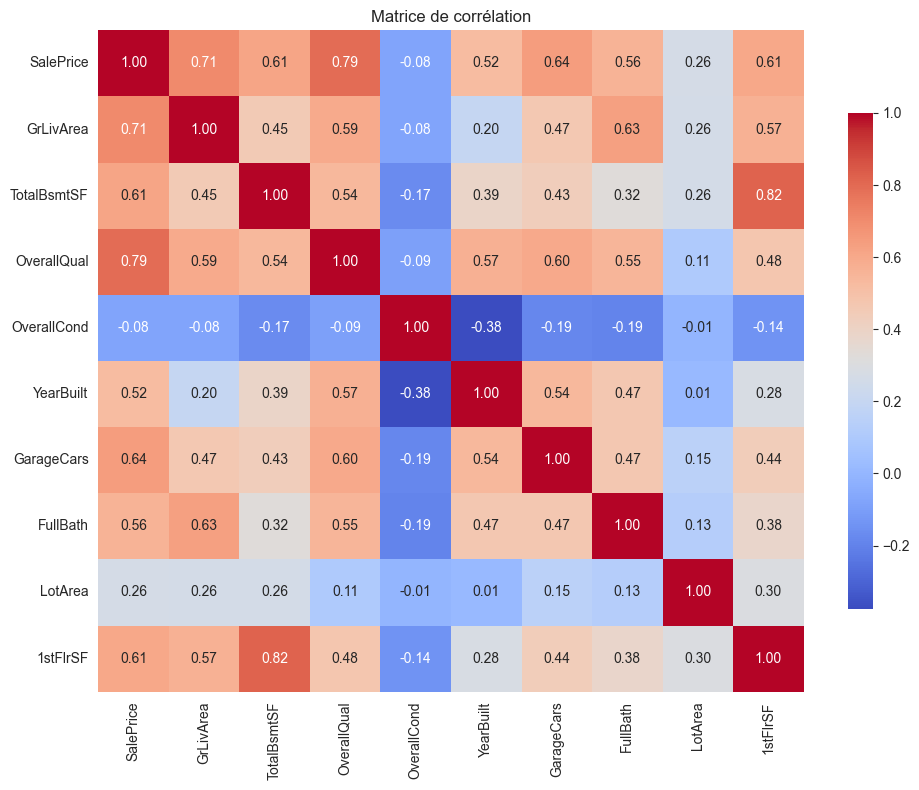

In [61]:
# Heatmap de corrélation (avant feature engineering)
corr_cols = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'OverallCond',
             'YearBuilt', 'GarageCars', 'FullBath', 'LotArea', '1stFlrSF']
corr_cols = [c for c in corr_cols if c in train_df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(train_df[corr_cols].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            cbar_kws={'shrink': 0.75})
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

---
## 3️⃣ Nettoyage — `src/preprocessing.py`

In [62]:
print('=== Nettoyage train ===')
train_df = handle_missing_values(train_df)
train_df = remove_outliers_iqr(train_df, 'SalePrice')

print('\n=== Nettoyage test ===')
test_df = handle_missing_values(test_df)

print(f'\nTrain après nettoyage : {train_df.shape}')
print(f'Valeurs manquantes restantes : {train_df.isnull().sum().sum()}')

=== Nettoyage train ===
  [remove_outliers_iqr] 'SalePrice' : 61 outlier(s) supprimé(s)

=== Nettoyage test ===

Train après nettoyage : (1399, 81)
Valeurs manquantes restantes : 0


---
## 4️⃣ Feature Engineering — `src/feature_engineering.py`

In [63]:
train_df = create_features(train_df)
test_df  = create_features(test_df)

print('Nouvelles features créées :')
print(train_df[['AgeLogement', 'SurfaceTotale', 'NbSallesDeBain']].describe())

Nouvelles features créées :
       AgeLogement  SurfaceTotale  NbSallesDeBain
count  1399.000000    1399.000000     1399.000000
mean     54.919228    2498.687634        1.725518
std      30.009463     741.721582        0.619254
min      16.000000     334.000000        0.000000
25%      26.000000    1991.500000        1.000000
50%      54.000000    2438.000000        2.000000
75%      72.000000    2940.500000        2.000000
max     153.000000   11752.000000        3.500000


---
## 5️⃣ Modélisation — `src/modeling.py`

In [64]:
# Séparation features / target
TARGET = 'SalePrice'
X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape} | Validation : {X_valid.shape}')

Train : (1119, 80) | Validation : (280, 80)


In [65]:
# Encodage + scaling
# On garde une copie de Neighborhood avant encodage pour l'analyse des biais
neighborhood_valid = X_valid['Neighborhood'].values if 'Neighborhood' in X_valid.columns else None

X_train_enc = encode_categorical(X_train)
X_valid_enc = encode_categorical(X_valid)

# Aligner les colonnes (l'encodage peut créer des colonnes différentes)
X_train_enc, X_valid_enc = X_train_enc.align(X_valid_enc, join='left', axis=1, fill_value=0)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_enc)
X_valid_sc  = scaler.transform(X_valid_enc)

print(f'Shape après encodage + scaling : {X_train_sc.shape}')

Shape après encodage + scaling : (1119, 254)


In [66]:
# Entraînement des 3 modèles
print('⏳ Régression Linéaire...')
lr_model = train_linear_regression(X_train_sc, y_train)

print('⏳ Random Forest...')
rf_model = train_random_forest(X_train_sc, y_train)

print('⏳ Gradient Boosting...')
gb_model = train_gradient_boosting(X_train_sc, y_train)

print('\n✅ Tous les modèles entraînés')

⏳ Régression Linéaire...
⏳ Random Forest...
⏳ Gradient Boosting...

✅ Tous les modèles entraînés


---
## 6️⃣ Comparaison des performances

In [67]:
models = {
    'Régression Linéaire': lr_model,
    'Random Forest':       rf_model,
    'Gradient Boosting':   gb_model
}

results = []
for name, model in models.items():
    r2, mae = evaluate_model(model, X_valid_sc, y_valid)
    results.append({'Modèle': name, 'R²': round(r2, 4), 'MAE ($)': round(mae, 0)})
    print(f'{name:25s} → R² = {r2:.4f} | MAE = {mae:,.0f} $')

comparison_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print()
display(comparison_df)

Régression Linéaire       → R² = -186.7257 | MAE = 766,294 $
Random Forest             → R² = 0.8626 | MAE = 14,571 $
Gradient Boosting         → R² = 0.8750 | MAE = 13,995 $



,Modèle,R²,MAE ($)
2,Gradient Boosting,0.8750,13995.0
1,Random Forest,0.8626,14571.0
0,Régression Linéaire,-186.7257,766294.0


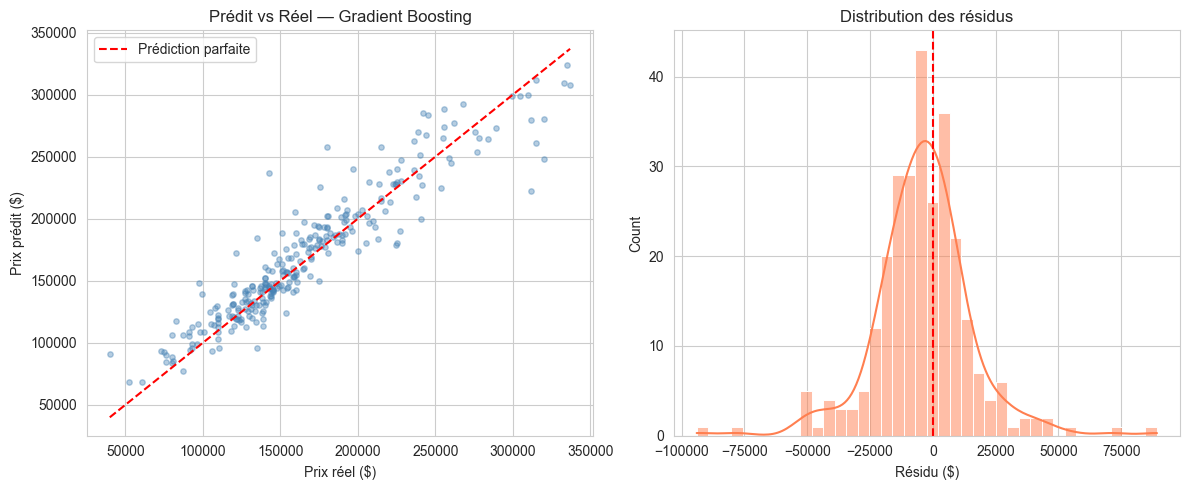

✅ Meilleur modèle : Gradient Boosting


In [68]:
# Prédit vs Réel + Résidus pour le meilleur modèle
best_name  = comparison_df.iloc[0]['Modèle']
best_model = models[best_name]
y_pred     = best_model.predict(X_valid_sc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_valid, y_pred, alpha=0.4, color='steelblue', s=15)
lims = [min(y_valid.min(), y_pred.min()), max(y_valid.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Prix réel ($)')
axes[0].set_ylabel('Prix prédit ($)')
axes[0].set_title(f'Prédit vs Réel — {best_name}')
axes[0].legend()

residuals = y_valid - y_pred
sns.histplot(residuals, bins=40, kde=True, color='coral', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Résidu ($)')
axes[1].set_title('Distribution des résidus')

plt.tight_layout()
plt.show()
print(f'✅ Meilleur modèle : {best_name}')

---
## 7️⃣ Analyse des biais par quartier

=== MAE par quartier (top 10 erreurs les plus élevées) ===


,Neighborhood,MAE_quartier,nb_maisons
0,ClearCr,31215.611886,5
1,SWISU,30280.041815,2
2,Blmngtn,23487.016790,4
3,NridgHt,22822.005164,10
4,Crawfor,20190.828271,10
5,Somerst,17216.321220,14
6,NoRidge,17099.216047,5
7,SawyerW,16642.912346,11
8,IDOTRR,14981.591797,8
9,CollgCr,14462.446765,29


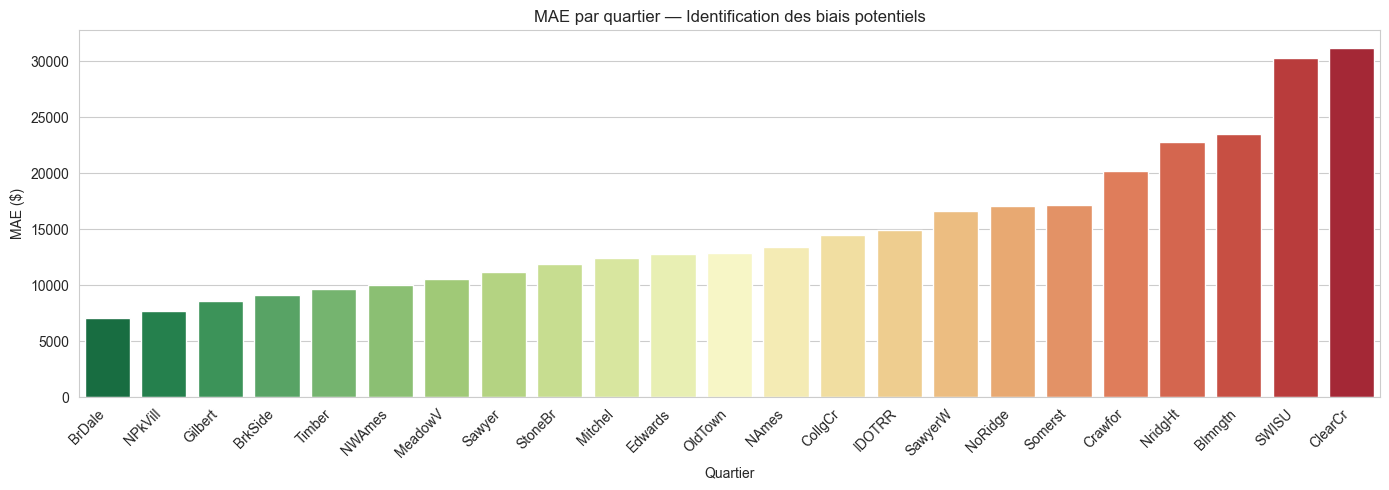

In [69]:
if neighborhood_valid is not None:
    bias_df = pd.DataFrame({
        'Neighborhood': neighborhood_valid,
        'y_real':       y_valid.values,
        'y_pred':       y_pred,
        'erreur':       np.abs(y_valid.values - y_pred)
    })

    biais = (bias_df.groupby('Neighborhood')
             .agg(MAE_quartier=('erreur', 'mean'),
                  nb_maisons=('erreur', 'count'))
             .sort_values('MAE_quartier', ascending=False)
             .reset_index())

    print('=== MAE par quartier (top 10 erreurs les plus élevées) ===')
    display(biais.head(10))

    plt.figure(figsize=(14, 5))
    order_b = biais.sort_values('MAE_quartier')['Neighborhood']
    sns.barplot(x='Neighborhood', y='MAE_quartier',
                data=biais, order=order_b, palette='RdYlGn_r')
    plt.xticks(rotation=45, ha='right')
    plt.title('MAE par quartier — Identification des biais potentiels')
    plt.xlabel('Quartier')
    plt.ylabel('MAE ($)')
    plt.tight_layout()
    plt.show()
else:
    print('Colonne Neighborhood absente — analyse ignorée.')

---
## 8️⃣ Sauvegarde du meilleur pipeline

In [70]:
os.makedirs('../models', exist_ok=True)

# Sauvegarde du scaler (utilisé pour transformer les nouvelles données)
joblib.dump(scaler,      '../models/scaler.pkl')

# Sauvegarde du meilleur modèle
joblib.dump(best_model,  '../models/random_forest_model.pkl')

# Sauvegarde des colonnes d'encodage (indispensable pour le Streamlit)
joblib.dump(X_train_enc.columns.tolist(), '../models/feature_columns.pkl')

print(f'✅ Sauvegardé : {best_name}')
print(f'   → models/random_forest_model.pkl')
print(f'   → models/scaler.pkl')
print(f'   → models/feature_columns.pkl')
print(f"   R² = {comparison_df.iloc[0]['R²']} | MAE = {comparison_df.iloc[0]['MAE ($)']:,.0f} $")

✅ Sauvegardé : Gradient Boosting
   → models/random_forest_model.pkl
   → models/scaler.pkl
   → models/feature_columns.pkl
   R² = 0.875 | MAE = 13,995 $
